## Toolset

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import cantera as ct
import majordome as mj
import numpy as np
import pyvista as pv

from pathlib import Path
from ruamel.yaml import YAML
from tabulate import tabulate

from IPython.display import Markdown, display

pv.set_jupyter_backend("static")

## Setup

In [3]:
# Total flow rate [Nm³/h].
qdot_fuel = 500.0

# Molar composition of fuel [-].
X_fuel = "CH4: 1"

# Molar composition of oxidizer [-].
X_oxid = "N2: 0.79, O2: 0.21"

# Mechanism for base calculations.
mech = "chemkin/BFER_methane.yaml"
phase = "CH4_BFER_multi"

# Burner diameters [mm].
diam_fuel     = 27
diam_oxid_ext = 342
diam_oxid_int = 76
thick_wall    = 2.5

### Energy input

In [4]:
normal_flow = mj.NormalFlowRate(mech, X=X_fuel, name=phase)
mdot_fuel = normal_flow(qdot_fuel) / 4

chon = mj.CombustionAtmosphereCHON(mech, phase=phase, basis="mole")
lhv = chon.solution_heating_value(X_fuel, X_oxid)

supply = mj.CombustionPowerSupply(
    power       = lhv * mdot_fuel * 1000,
    equivalence = 1.0,
    fuel        = X_fuel,
    oxidizer    = X_oxid,
    mechanism   = mech,
    phase       = phase,
    basis       = "mole",
)

_ = supply.report(notebook=True)

| Property                  | Unit   |     Value |
|---------------------------|--------|-----------|
| Required power            | kW     | 1243.27   |
| Lower heating value       | MJ/kg  |   50.0254 |
| Fuel mass flow rate       | kg/h   |   89.4699 |
| Oxidizer mass flow rate   | kg/h   | 1532.35   |
| Total mass flow rate      | kg/h   | 1621.82   |
| Fuel volume flow rate     | Nm³/h  |  125      |
| Oxidizer volume flow rate | Nm³/h  | 1190.48   |
| Total volume flow rate    | Nm³/h  | 1315.48   |
| Water production          | kg/h   |  200.935  |
| Carbon dioxide production | kg/h   |  245.433  |
| Total emissions           | kg/h   |  446.368  |

### Geometry

In [5]:
A_fuel_pipe = np.pi * (diam_fuel / 2 + thick_wall)**2
A_fuel_one  = np.pi * (diam_fuel / 2)**2
A_fuel_tot  = 4 * A_fuel_pipe

A_air_ext = np.pi * (diam_oxid_ext / 2)**2
A_air_int = np.pi * (diam_oxid_int / 2)**2

A_air = A_air_ext - A_air_int - A_fuel_tot
A_air_one = A_air / 4

e_wall = float(0.001 * thick_wall)
D_fuel = float(0.001 * diam_fuel)
D_oxid = float(0.001 * np.sqrt(4 * (A_air_one + A_fuel_pipe) / np.pi))

In [6]:
geometry_data = {
    "wedge_angle": 2.0,
    "len_inlet_ax": 3 * D_fuel,
    "len_inlet_an": 3 * D_fuel,
    "len_disperse": 1.00,
    "len_flue_out": 2.00,
    "dia_inlet_ax": D_fuel,
    "thk_inlet_wl": e_wall,
    "thk_inlet_an": D_oxid / 2,
    "thk_side_box": 2 * D_oxid,
}

yaml = YAML()
yaml.default_flow_style = False
yaml.indent(mapping=2, sequence=4, offset=2)

output_file = Path("domain.yaml")
with output_file.open("w", encoding="utf-8") as f:
    yaml.dump(geometry_data, f)

### Kinetics data

In [7]:
sutherland = mj.SutherlandFitting(mech, name=phase)
sutherland.fit(np.linspace(400, 2300, 100))

transport = Path(mech).parent / "transport"
transport.unlink(missing_ok=True)

_ = sutherland.as_openfoam_dict(transport)

In [8]:
#| echo: false
# Use the following for inspection:
# figs = Path(mech).parent / "media"
# figs.mkdir(exist_ok=True)

# for s in coef["species"]:
#     p = sutherland.plot_species(s)
#     p.savefig(figs / f"{s}.png")

In [9]:
#| echo: false
#| tbl-cap: Sutherland fitting coefficients for transport properties.
#| label: tbl-sutherland-coefs
sutherland.coefs_table

,species,As [uPa.s],Ts [K],RMSE [uPa.s]
0,O2,1.845210,207.527886,0.528664
1,H2O,2.281734,974.848255,0.217912
2,CH4,1.076964,224.165687,0.263242
3,CO,1.569128,203.847264,0.466735
4,CO2,1.688398,296.196009,0.213426
5,N2,1.596546,203.635451,0.475951


### Conditions setup

In [10]:
def mean_velocity(mdot, rho, T, A):
    """ Temperature corrected mean flow velocity. """
    return mdot / (rho * A)


def characteristic_length(A, f=0.07):
    """ Characteristic length for turbulence. """
    return f * np.sqrt(4.0 * A / np.pi)


def turbulent_kinetic_energy(U, I=0.05):
    """ Computes the turbulent kinetic energy. """
    return 1.5 * (U * I)**2


def turbulent_dissipation_rate(k, L, C_mu=0.09):
    """ Computes the turbulent dissipation rate. """
    return (C_mu**0.75) * (k**1.5) / L

In [11]:
setup_dict = mj.FoamDictFile(path="0.orig/_shared")


def flow_workflow(name, mdot, rho0, T, A, I=0.05):
    rho = (273.15 / T) * rho0

    U = mean_velocity(mdot, rho, T, A)
    L = characteristic_length(A)
    k = turbulent_kinetic_energy(U, I)
    e = turbulent_dissipation_rate(k, L)

    key_name = name.upper()
    setup_dict.set(f"{key_name}_T", T)
    setup_dict.set(f"{key_name}_U", U)
    setup_dict.set(f"{key_name}_RHO", rho)
    setup_dict.set(f"{key_name}_L", L)
    setup_dict.set(f"{key_name}_I", I)
    setup_dict.set(f"{key_name}_K", k)
    setup_dict.set(f"{key_name}_EPSILON", e)
    setup_dict.save()

    return tabulate(
        [
            ("Temperature", "K", T),
            ("Mean velocity", "m/s", U),
            ("Characteristic length", "mm", 1000*L),
            ("Turbulent kinetic energy", "m²/s²", k),
            ("Turbulent dissipation rate", "m²/s³", e),
        ],
        headers  = ["Quantity", "Unit", "Value"],
        tablefmt = "github"
    )

In [12]:
hot_air = 0

table_fuel = flow_workflow(
    name = "FUEL",
    mdot = supply.fuel_mass,
    rho0 = supply.fuel_normal_density,
    T    = 298.15,
    A    = 1.0e-06 * A_fuel_one
)

table_oxid = flow_workflow(
    name = "OXID",
    mdot = supply.oxidizer_mass,
    rho0 = supply.oxidizer_normal_density,
    T    = 298.15 + hot_air * 300,
    A    = 1.0e-06 * A_air_one
)

In [13]:
#| echo: false
#| tbl-cap: Conditions evaluated for fuel.
#| label: tbl-conditions-fuel
display(Markdown(table_fuel))

| Quantity                   | Unit   |     Value |
|----------------------------|--------|-----------|
| Temperature                | K      |  298.15   |
| Mean velocity              | m/s    |   66.1948 |
| Characteristic length      | mm     |    1.89   |
| Turbulent kinetic energy   | m²/s²  |   16.4316 |
| Turbulent dissipation rate | m²/s³  | 5790.79   |

In [14]:
#| echo: false
#| tbl-cap: Conditions evaluated for oxidizer.
#| label: tbl-conditions-oxidizer
display(Markdown(table_oxid))

| Quantity                   | Unit   |    Value |
|----------------------------|--------|----------|
| Temperature                | K      | 298.15   |
| Mean velocity              | m/s    |  17.1658 |
| Characteristic length      | mm     |  11.4537 |
| Turbulent kinetic energy   | m²/s²  |   1.105  |
| Turbulent dissipation rate | m²/s³  |  16.6639 |

## Postprocessing

In [15]:
def read_data(
        case_file: str | Path = "case.foam",
        decomposed: bool = True,
        time_index: int = -1
    ) -> pv.DataObject | None:
    """ Read case data for post-processing. """
    if not Path(case_file).exists():
        raise FileNotFoundError(f"No such case {case_file}")

    reader = pv.POpenFOAMReader(case_file)
    reader.enable_all_cell_arrays()
    reader.enable_all_point_arrays()

    if decomposed and list(Path(".").glob("processor*")):
        reader.case_type = "decomposed"

    try:
        case_time = reader.time_values[time_index]
        print(f"Loading results for iter. {case_time}")

        reader.set_active_time_value(case_time)
        return reader.read()
    except AttributeError:
        print(f"Case was not ready to be read")
        return

In [16]:
def load_slice(*args, **kwargs) -> pv.PolyData | None:
    """ Standard slicing of mid-plane of domain. """
    if (mesh := kwargs.pop("mesh", None)) is None:
        if (mesh := read_data(*args, **kwargs)) is None:
            return

    return (
        mesh["internalMesh"]
            .slice(normal="z", origin=(0.0, 0.0, 0.0))
            .cell_data_to_point_data()
    )

In [17]:
def plot_slice(
        mesh,
        saveas: str | Path | None = None,
        off_screen: bool = False,
        window_size: tuple[int, int] = (900, 250),
        **kwargs
    ) -> None:
    """ Custom display of slice results. """
    if off_screen and not saveas:
        print("Running headless without `saveas` has no effect, exit.")
        return

    kwargs.setdefault("cmap", "jet")
    kwargs.setdefault("scalar_bar_args", {
        "vertical": False,
        "height": 0.08,
        "width": 0.8,
        "position_x": 0.1,
        "title_font_size": 12,
        "label_font_size": 10,
    })

    pl = pv.Plotter(off_screen=off_screen)
    pl.add_mesh(mesh, **kwargs, show_edges=False)

    pl.camera_position = "xy"
    pl.window_size = window_size

    pl.enable_parallel_projection()
    pl.enable_2d_style()
    pl.enable_zoom_style()

    pl.add_ruler(
        pointa=[0.000, -0.02, 0.0],
        pointb=[3.001, -0.02, 0.0],
        title="Coordinate [m]"
    )
    region_bounds = [-0.1, 3.0, 0.0, 0.3, -0.01, 0.01]
    pl.view_xy(bounds=region_bounds)
    pl.zoom_camera(3.5)

    # pl.show_bounds()
    # pl.show_axes()
    pl.show()

    if saveas is not None:
        pl.screenshot(saveas)

In [18]:
mesh = load_slice()

Loading results for iter. 2150.0


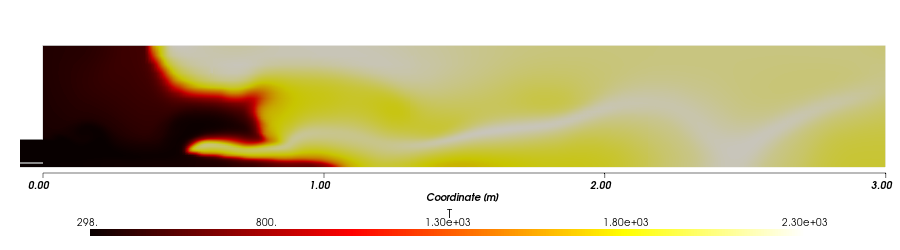

In [ ]:
#| echo: false
#| fig-align: center
#| fig-cap: Temperature field for reference case.
#| label: fig-field-temperature-1
plot_slice(mesh, scalars="T", cmap="hot")

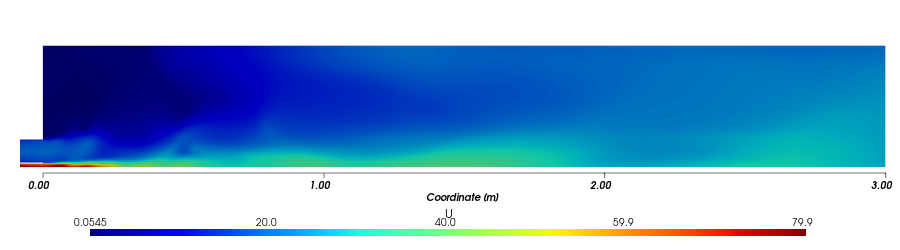

In [21]:
#| echo: false
#| fig-align: center
#| fig-cap: Velocity magnitude field for reference case.
#| label: fig-field-velocity-1
plot_slice(mesh, scalars="U", cmap="jet")